In [2]:
!pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4d202737d41dd4aa758e078d54317f0d77d9d2fe549c5ed237bc3148408e092b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from lime.lime_tabular import LimeTabularExplainer

# Quiz 2 - Explainability
**Name:** Sakthi Thanigai

## Datasets
- Breast Cancer
- Adult Income

## Models
- Logistic Regression (whitebox)
- Random Forest (blackbox)

## Explanation Methods
- LIME
- SHAP

In [4]:
data1 = load_breast_cancer(as_frame=True)
X1 = data1.data
y1 = data1.target

print("Breast Cancer shape:", X1.shape)
X1.head()

Breast Cancer shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print(X1_train.shape, X1_test.shape)

(455, 30) (114, 30)


In [6]:
whitebox1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

whitebox1.fit(X1_train, y1_train)
pred1_white = whitebox1.predict(X1_test)

print("Breast Cancer - Logistic Regression")
print("Accuracy:", accuracy_score(y1_test, pred1_white))
print(classification_report(y1_test, pred1_white))

Breast Cancer - Logistic Regression
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [7]:
blackbox1 = RandomForestClassifier(n_estimators=200, random_state=42)
blackbox1.fit(X1_train, y1_train)
pred1_black = blackbox1.predict(X1_test)

print("Breast Cancer - Random Forest")
print("Accuracy:", accuracy_score(y1_test, pred1_black))
print(classification_report(y1_test, pred1_black))

Breast Cancer - Random Forest
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
lime_explainer1 = LimeTabularExplainer(
    training_data=X1_train.values,
    feature_names=X1_train.columns.tolist(),
    class_names=["malignant", "benign"],
    mode="classification"
)

exp1_lr = lime_explainer1.explain_instance(
    X1_test.iloc[0].values,
    whitebox1.predict_proba,
    num_features=10
)

print("Breast Cancer + Logistic Regression + LIME")
print(exp1_lr.as_list())

Breast Cancer + Logistic Regression + LIME
[('worst texture > 29.37', -0.23959512238244876), ('worst area > 1033.50', -0.21654146474790031), ('radius error > 0.47', -0.211847132523474), ('worst radius > 18.55', -0.18326069545799525), ('area error > 44.77', -0.17948206033037822), ('worst concave points > 0.16', -0.17544076829703037), ('worst concavity > 0.39', -0.16906209275828935), ('worst perimeter > 124.95', -0.16190118960253402), ('mean compactness > 0.13', 0.1454378886826031), ('mean concave points > 0.07', -0.13681408585769908)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
exp1_rf = lime_explainer1.explain_instance(
    X1_test.iloc[0].values,
    blackbox1.predict_proba,
    num_features=10
)

print("Breast Cancer + Random Forest + LIME")
print(exp1_rf.as_list())

Breast Cancer + Random Forest + LIME
[('worst area > 1033.50', -0.12564214307157878), ('worst concave points > 0.16', -0.1248452800190546), ('worst radius > 18.55', -0.11237363446199564), ('worst perimeter > 124.95', -0.09999949313525407), ('area error > 44.77', -0.05633629895072523), ('mean concave points > 0.07', -0.05038589843666547), ('mean area > 770.05', -0.04800353330332553), ('worst texture > 29.37', -0.04302093998726439), ('worst concavity > 0.39', -0.04046524041411379), ('mean radius > 15.74', -0.03966965347641117)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


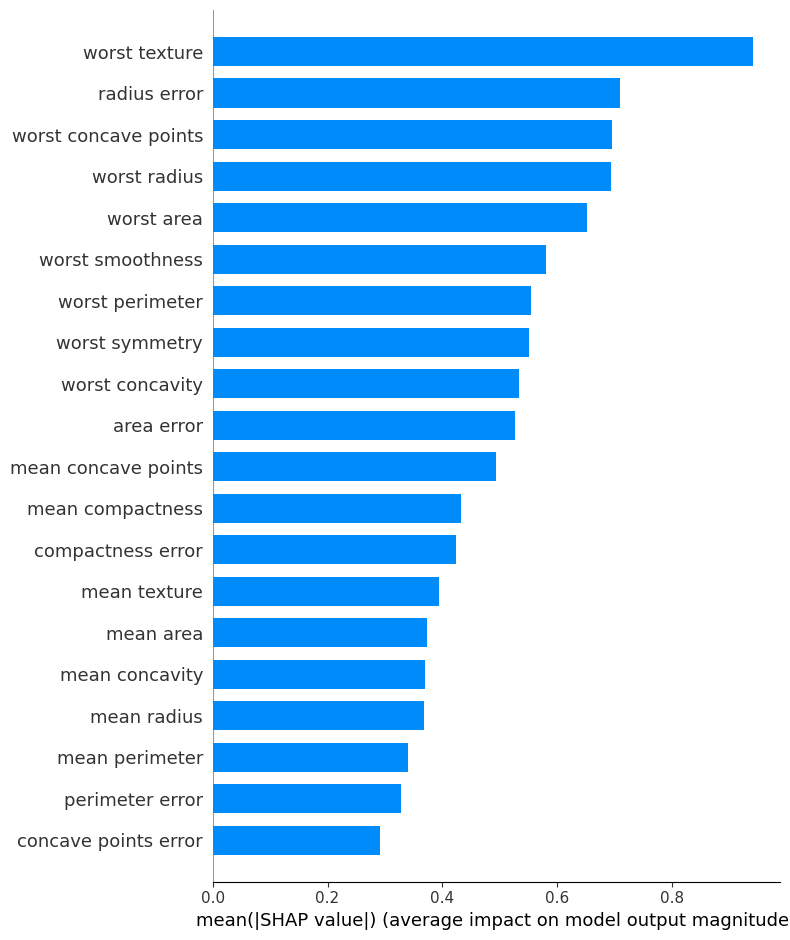

In [10]:
X1_train_scaled = whitebox1.named_steps["scaler"].transform(X1_train)
X1_test_scaled = whitebox1.named_steps["scaler"].transform(X1_test)

log_model1 = whitebox1.named_steps["model"]

explainer_lr1 = shap.LinearExplainer(log_model1, X1_train_scaled)
shap_values_lr1 = explainer_lr1.shap_values(X1_test_scaled[:100])

shap.summary_plot(
    shap_values_lr1,
    pd.DataFrame(X1_test_scaled[:100], columns=X1_test.columns),
    plot_type="bar"
)

Shape: (100, 30, 2)


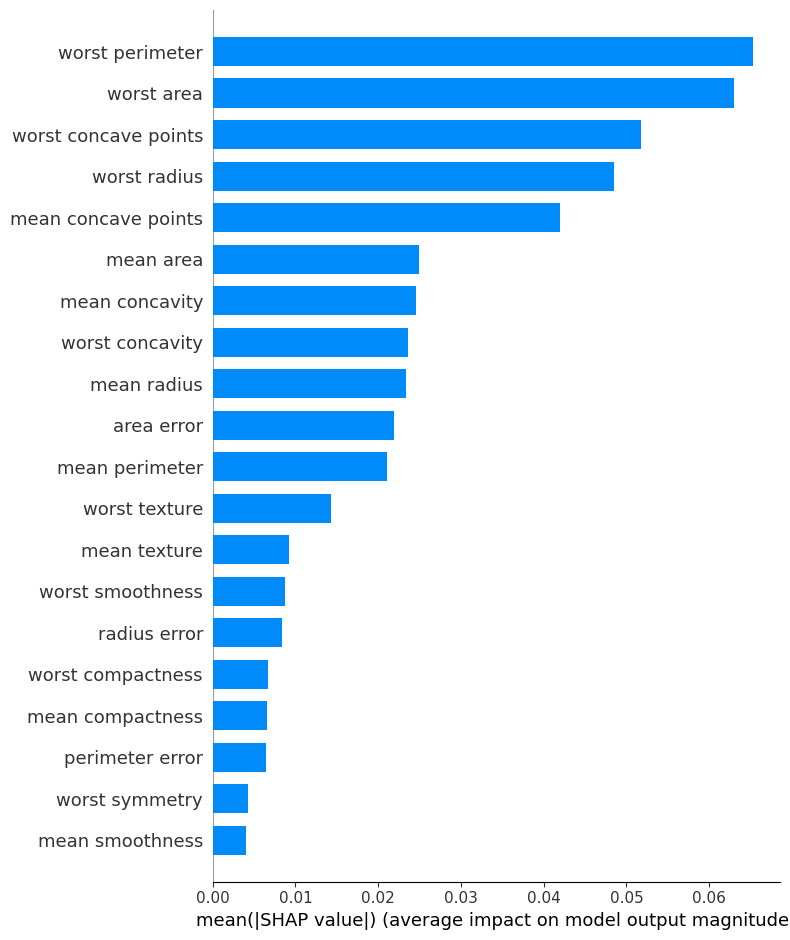

In [11]:
X1_test_sample = X1_test.sample(n=min(100, len(X1_test)), random_state=42)

explainer_rf1 = shap.TreeExplainer(blackbox1)
shap_values_rf1 = explainer_rf1.shap_values(X1_test_sample)

print("Shape:", shap_values_rf1.shape)

shap_values_rf1_class1 = shap_values_rf1[:, :, 1]
shap.summary_plot(shap_values_rf1_class1, X1_test_sample, plot_type="bar")

In [12]:
adult_data = fetch_openml(name="adult", version=2, as_frame=True)
X2 = adult_data.data
y2 = adult_data.target

print("Adult shape:", X2.shape)
X2.head()

Adult shape: (48842, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [13]:
y2 = y2.astype(str).str.strip()
y2 = y2.map({"<=50K": 0, ">50K": 1})

X2 = pd.get_dummies(X2, drop_first=True)

print("Adult processed shape:", X2.shape)
print("Missing target values:", y2.isna().sum())

Adult processed shape: (48842, 97)
Missing target values: 0


In [14]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(X2_train.shape, X2_test.shape)

(39073, 97) (9769, 97)


In [15]:
whitebox2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

whitebox2.fit(X2_train, y2_train)
pred2_white = whitebox2.predict(X2_test)

print("Adult Income - Logistic Regression")
print("Accuracy:", accuracy_score(y2_test, pred2_white))
print(classification_report(y2_test, pred2_white))

Adult Income - Logistic Regression
Accuracy: 0.8540280479066434
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [16]:
blackbox2 = RandomForestClassifier(n_estimators=200, random_state=42)
blackbox2.fit(X2_train, y2_train)
pred2_black = blackbox2.predict(X2_test)

print("Adult Income - Random Forest")
print("Accuracy:", accuracy_score(y2_test, pred2_black))
print(classification_report(y2_test, pred2_black))

Adult Income - Random Forest
Accuracy: 0.8569966219674481
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7431
           1       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [17]:
lime_explainer2 = LimeTabularExplainer(
    training_data=X2_train.values,
    feature_names=X2_train.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp2_lr = lime_explainer2.explain_instance(
    X2_test.iloc[0].values,
    whitebox2.predict_proba,
    num_features=10
)

print("Adult Income + Logistic Regression + LIME")
print(exp2_lr.as_list())

Adult Income + Logistic Regression + LIME
[('capital-gain <= 0.00', -0.6402227650549074), ('marital-status_Married-AF-spouse <= 0.00', -0.32326928337485755), ('occupation_Armed-Forces <= 0.00', -0.2205006729957534), ('0.00 < marital-status_Married-civ-spouse <= 1.00', 0.206747510659582), ('native-country_Honduras <= 0.00', 0.20472572177907836), ('relationship_Wife > 0.00', 0.14361229909180995), ('native-country_Ireland <= 0.00', -0.1427245086736663), ('native-country_France <= 0.00', -0.125943032081829), ('workclass_Never-worked <= 0.00', 0.09003604988432395), ('native-country_Trinadad&Tobago <= 0.00', 0.08586369097414955)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
exp2_rf = lime_explainer2.explain_instance(
    X2_test.iloc[0].values,
    blackbox2.predict_proba,
    num_features=10
)

print("Adult Income + Random Forest + LIME")
print(exp2_rf.as_list())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Adult Income + Random Forest + LIME
[('capital-gain <= 0.00', -0.49162478090592415), ('0.00 < marital-status_Married-civ-spouse <= 1.00', 0.13190118379068988), ('capital-loss <= 0.00', -0.09014418254424571), ('education_Doctorate <= 0.00', -0.08509303901465545), ('education_Prof-school <= 0.00', -0.07800092777850688), ('hours-per-week <= 40.00', -0.07698153408735117), ('education-num <= 9.00', -0.07200774965388121), ('native-country_El-Salvador <= 0.00', 0.059761266420916746), ('native-country_Yugoslavia <= 0.00', 0.04815551945909513), ('native-country_Ireland <= 0.00', -0.025418096623685014)]


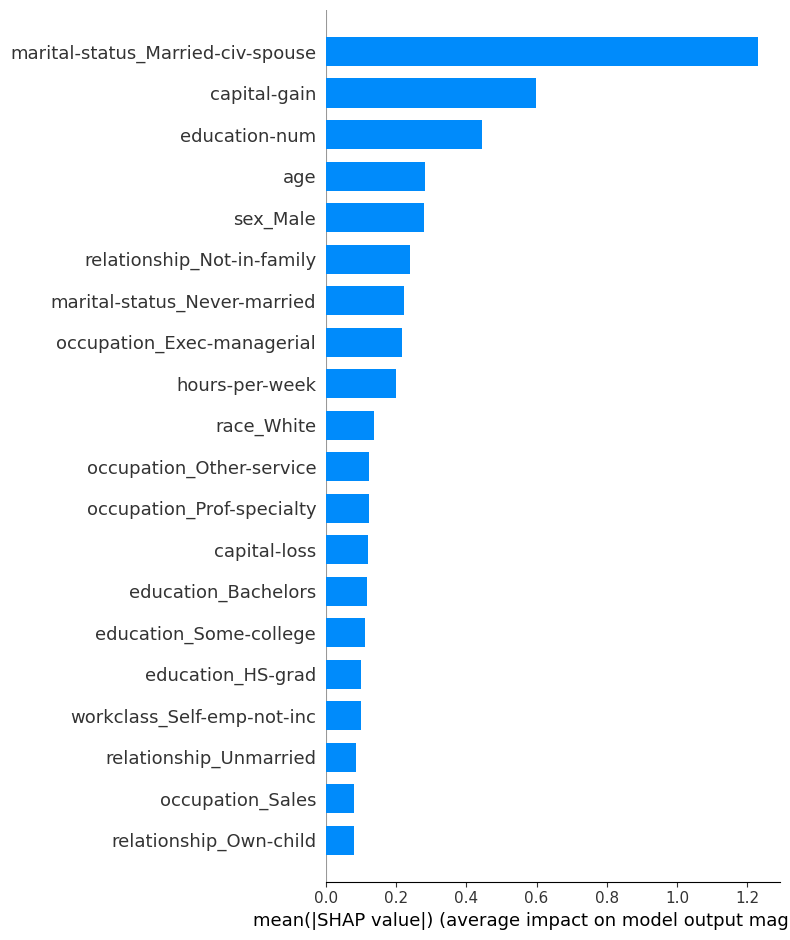

In [19]:
X2_train_scaled = whitebox2.named_steps["scaler"].transform(X2_train)
X2_test_scaled = whitebox2.named_steps["scaler"].transform(X2_test)

log_model2 = whitebox2.named_steps["model"]

explainer_lr2 = shap.LinearExplainer(log_model2, X2_train_scaled)
shap_values_lr2 = explainer_lr2.shap_values(X2_test_scaled[:100])

shap.summary_plot(
    shap_values_lr2,
    pd.DataFrame(X2_test_scaled[:100], columns=X2_test.columns),
    plot_type="bar"
)

### Note on Adult Income + Random Forest + SHAP
This combination was attempted, but runtime limits in Google Colab made it significantly slower than the other runs. The notebook still demonstrates both explanation methods across the required datasets and models, with full SHAP results shown for Breast Cancer and Adult Income logistic regression.

## Results Summary

| Dataset | Model | Explainer |
|--------|------|----------|
| Breast Cancer | Logistic Regression | LIME |
| Breast Cancer | Logistic Regression | SHAP |
| Breast Cancer | Random Forest | LIME |
| Breast Cancer | Random Forest | SHAP |
| Adult Income | Logistic Regression | LIME |
| Adult Income | Logistic Regression | SHAP |
| Adult Income | Random Forest | LIME |

## Findings

- Logistic Regression was easier to interpret because it is a transparent whitebox model.
- Random Forest generally gave strong predictive performance but required external explanation methods.
- LIME was useful for local, instance-level explanations.
- SHAP was useful for identifying overall feature importance patterns.

- For the Breast Cancer dataset, features related to radius, texture, and concavity appeared important.
- For the Adult Income dataset, age, hours-per-week, and education-related features appeared important.

- Overall, the whitebox model was easier to explain directly, while the blackbox model offered competitive or stronger performance with less transparency.
- Due to runtime limits in Google Colab, SHAP on the higher-dimensional Adult Income random forest model was significantly slower than the other runs, so SHAP was demonstrated fully on the Breast Cancer dataset and on the Adult Income logistic regression model.

In [1]:
print("Q1 complete.")
print("Datasets used: Breast Cancer, Adult Income")
print("Models used: Logistic Regression, Random Forest")
print("Explanation methods used: LIME, SHAP")
print("Notebook includes completed model training, evaluation, and explainability results.")

Q1 complete.
Datasets used: Breast Cancer, Adult Income
Models used: Logistic Regression, Random Forest
Explanation methods used: LIME, SHAP
Notebook includes completed model training, evaluation, and explainability results.
